In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/processed_dataset.csv")

## Travail sur un site spécifique

In [4]:
site_name = df['site_name'].unique()[1]
print(site_name)

Mermaid Offshore WP


In [5]:
data = df[df['site_name'] == site_name].copy()
data = data.sort_values('delivery_time')

In [6]:
data['installed_capacity'].unique()

array([235.5])

In [7]:
wind_threshold = 5.0
prod_threshold = 0.05

In [8]:
data['is_maintenance'] = (
        (data['wind_speed_100m'] > wind_threshold) & 
        (data['production'] < data["installed_capacity"]*prod_threshold)
    ).astype(int)

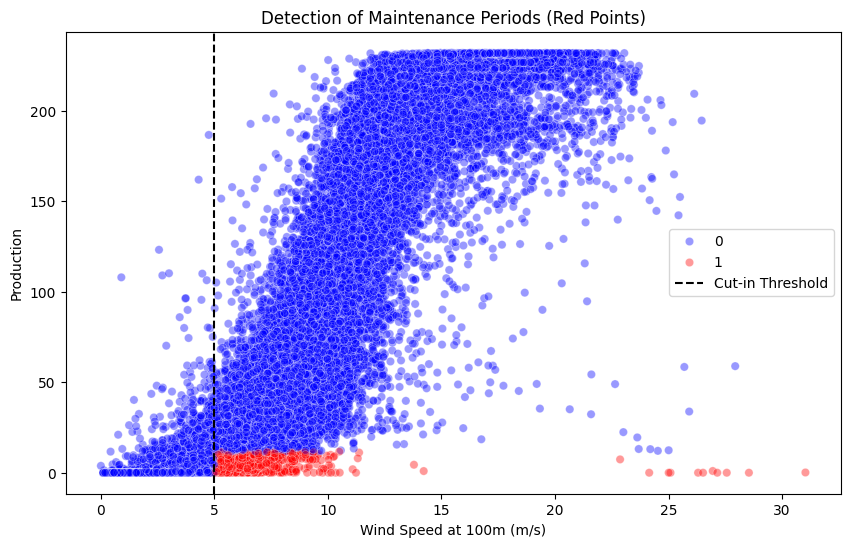

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=data, 
    x='wind_speed_100m', 
    y='production', 
    hue='is_maintenance',
    palette={0: 'blue', 1: 'red'},
    alpha=0.4
)
plt.title('Detection of Maintenance Periods (Red Points)')
plt.xlabel('Wind Speed at 100m (m/s)')
plt.ylabel('Production')
plt.axvline(x=5.0, color='black', linestyle='--', label='Cut-in Threshold')
plt.legend()
plt.show()

In [10]:
def plot_production_time_series_with_maintenance(df, site_name, wind_threshold, prod_threshold):
    data = df[df['site_name'] == site_name].copy()
    
    data['delivery_time'] = pd.to_datetime(data['delivery_time'])
    data = data.sort_values('delivery_time')
    
    # 2. Logique de maintenance
    data['is_maintenance'] = (
        (data['wind_speed_100m'] > wind_threshold) & 
        (data['production'] < data["installed_capacity"]*prod_threshold)
    ).astype(int)

    # 3. Graphique
    plt.figure(figsize=(16, 6))
    
    # Tracer la production
    plt.plot(data['delivery_time'], data['production'], color='dodgerblue', 
             label='Production réelle', alpha=0.7)

    # Tracer les maintenances
    maint_data = data[data['is_maintenance'] == 1]
    plt.scatter(maint_data['delivery_time'], maint_data['production'], 
                color='red', label='Maintenance détectée', s=15, zorder=5)

    # 4. Zoom (C'est ici que ça bloquait)
    # On définit les bornes en s'assurant qu'elles sont compatibles
    start_date = pd.Timestamp('2023-01-01')
    end_date = pd.Timestamp('2023-02-01')
    plt.xlim(start_date, end_date)

    plt.title(f'Série Temporelle de Production : {site_name}')
    plt.ylabel('Production (MW)')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

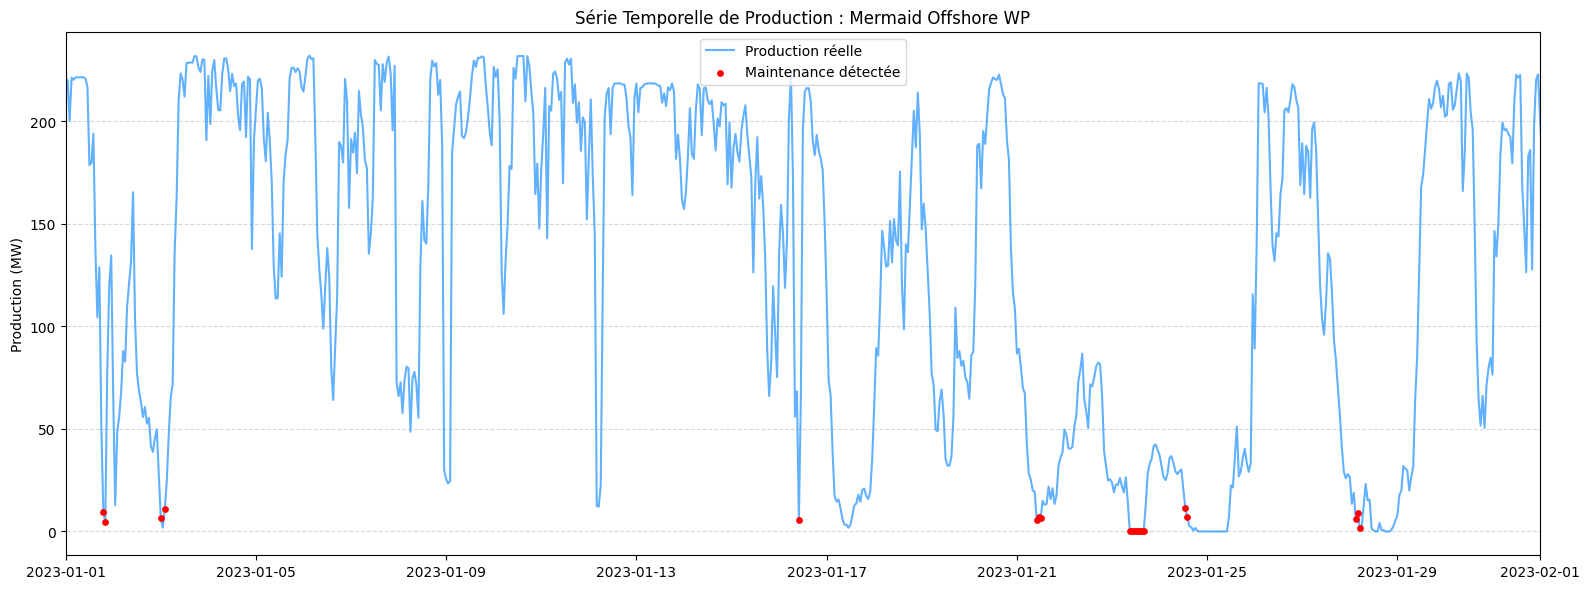

In [11]:
plot_production_time_series_with_maintenance(data, site_name, wind_threshold=wind_threshold, prod_threshold=prod_threshold)

## Visualisation pour tous les sites

In [12]:
df["site_name"].unique()

<ArrowStringArray>
[                 'Belwind Phase 1',              'Mermaid Offshore WP',
      'Nobelwind Offshore Windpark',              'Norther Offshore WP',
                    'Northwester 2',                        'Northwind',
               'Rentel Offshore WP',              'Seastar Offshore WP',
 'Thorntonbank - C-Power - Area NE', 'Thorntonbank - C-Power - Area SW']
Length: 10, dtype: str

Belwind Phase 1


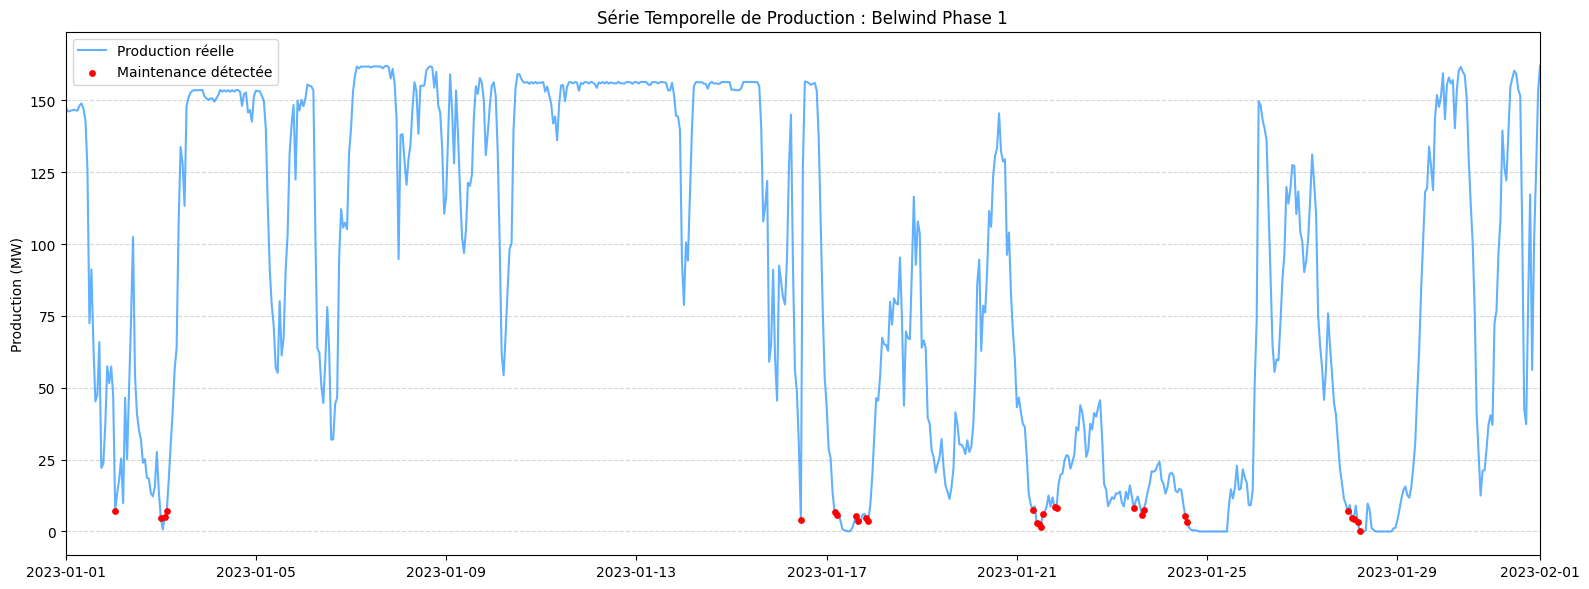

Mermaid Offshore WP


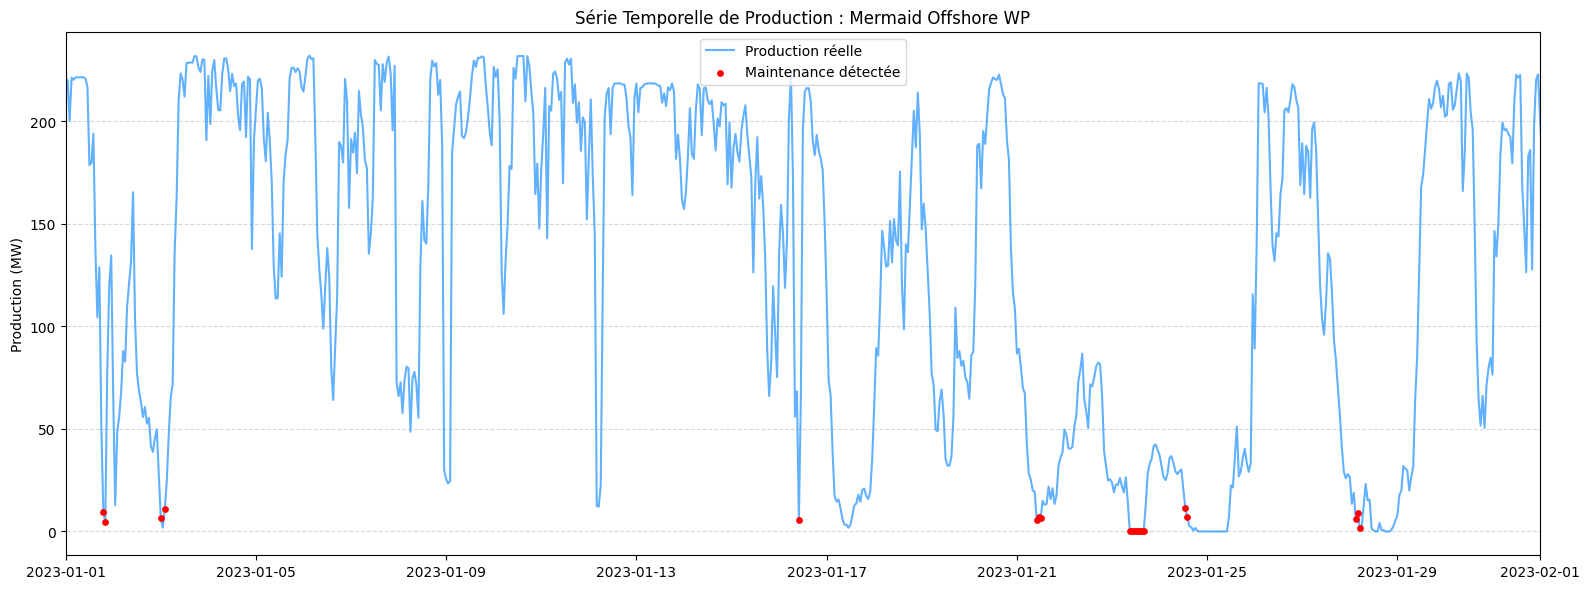

Nobelwind Offshore Windpark


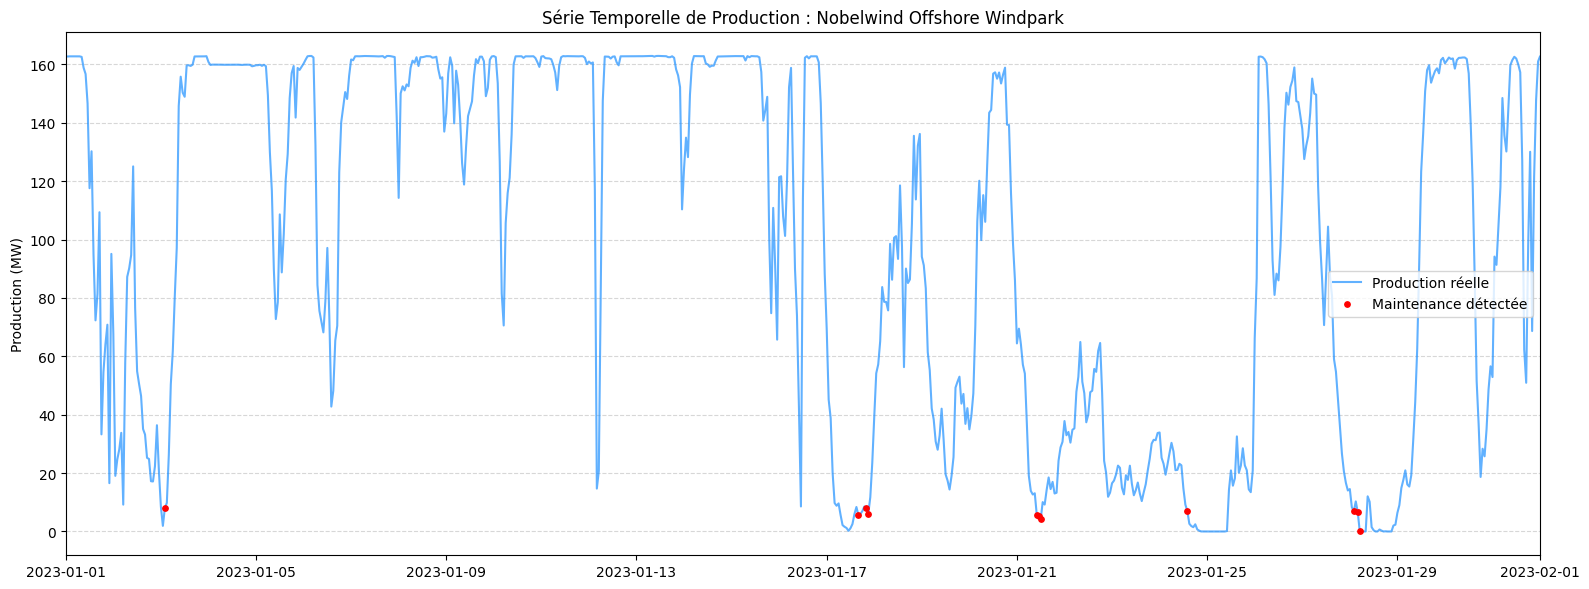

Norther Offshore WP


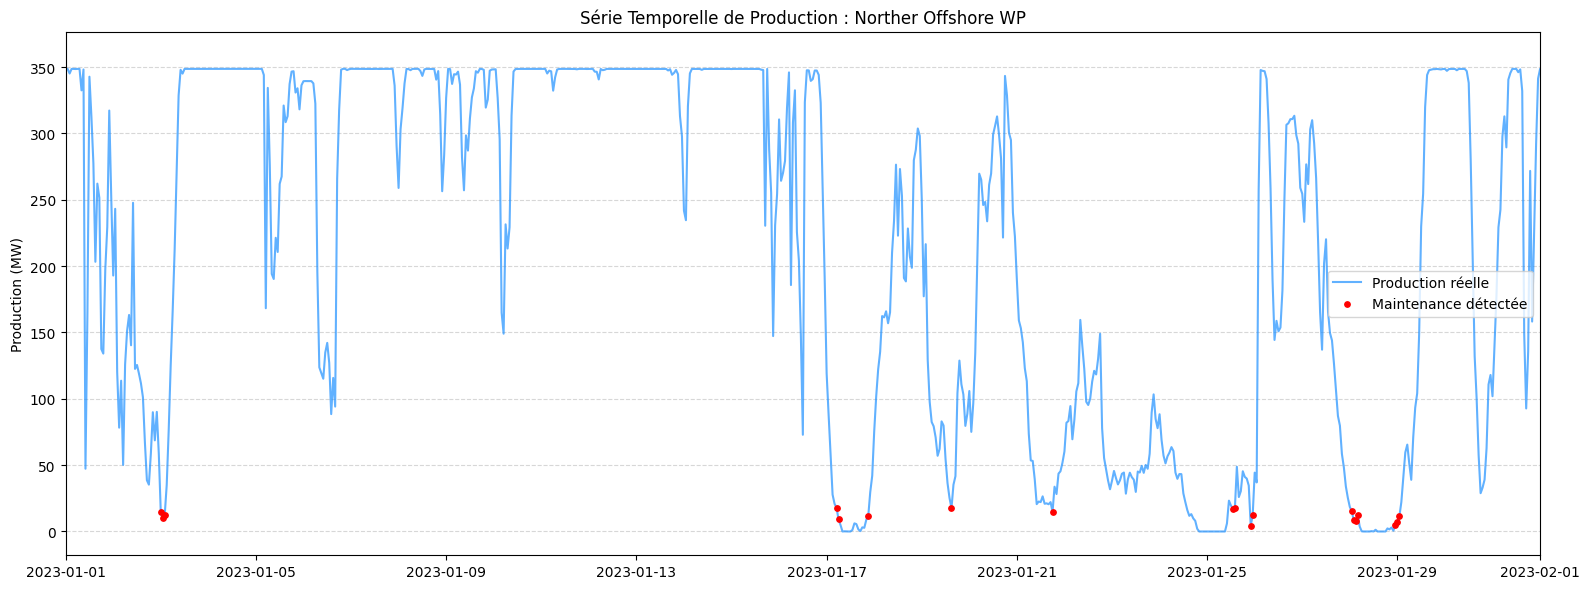

Northwester 2


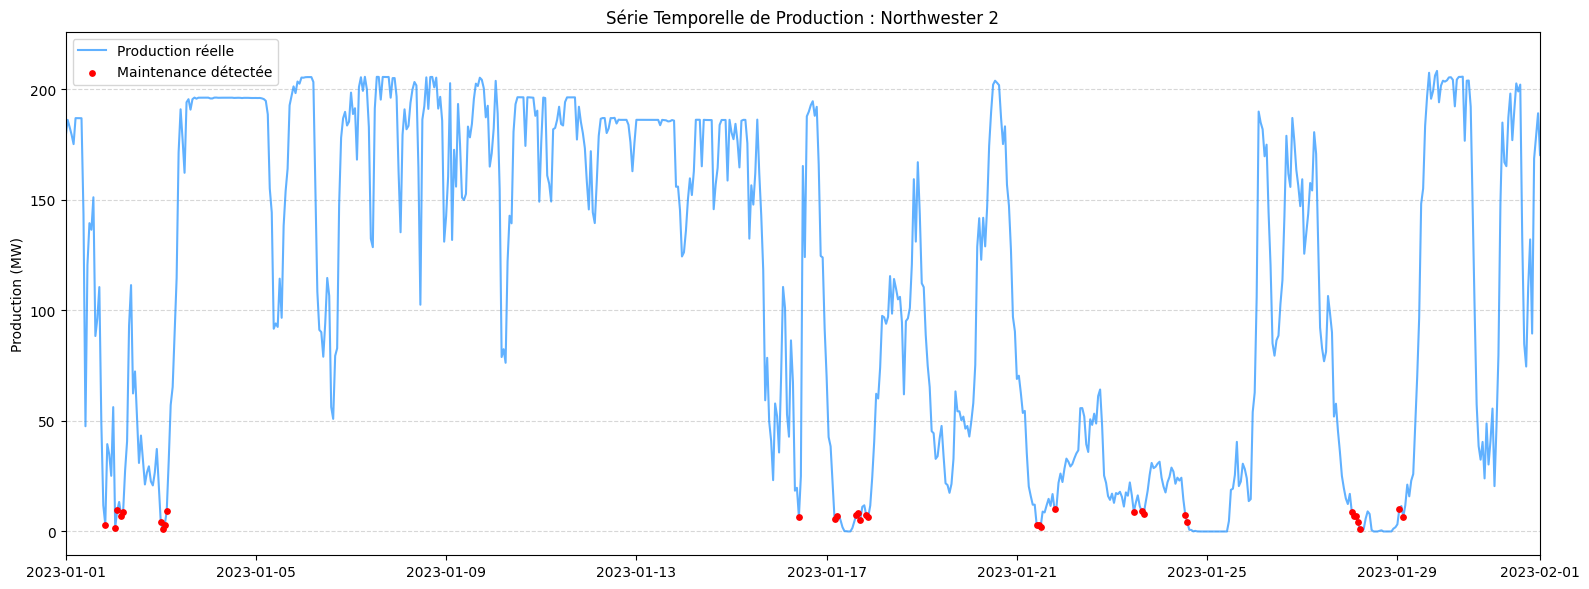

Northwind


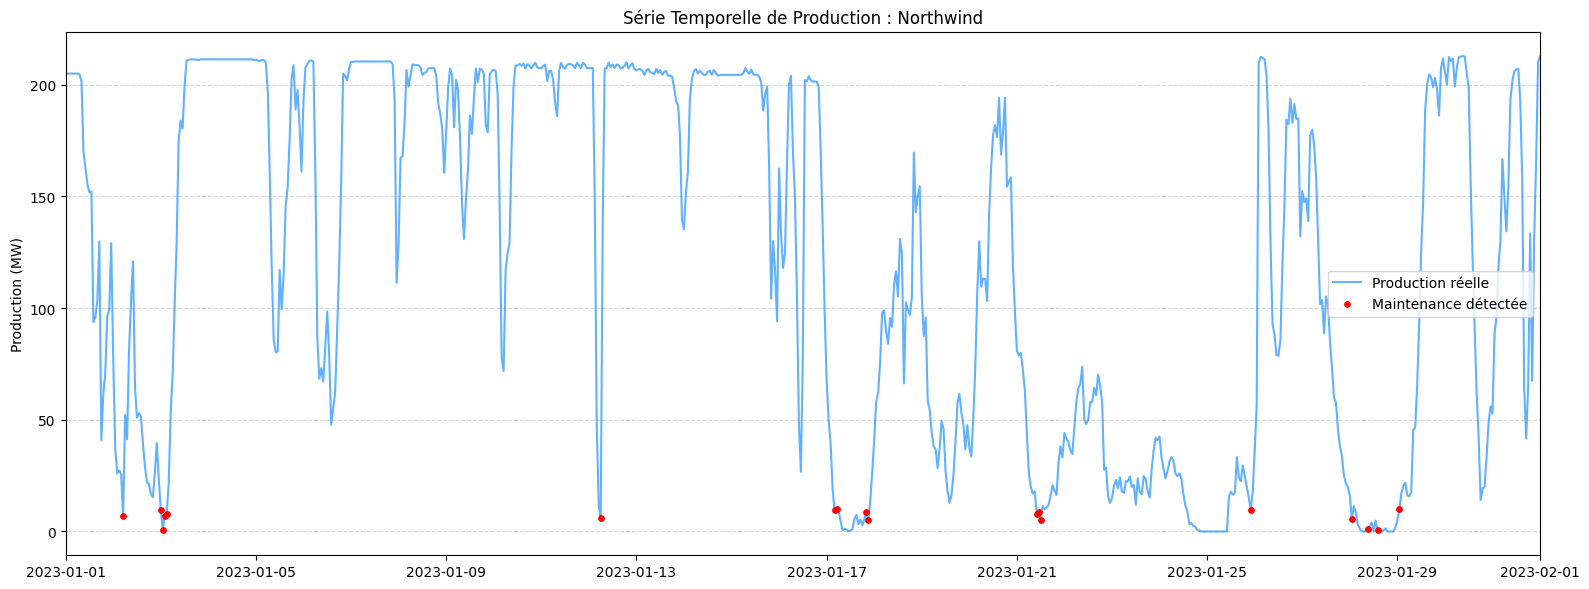

Rentel Offshore WP


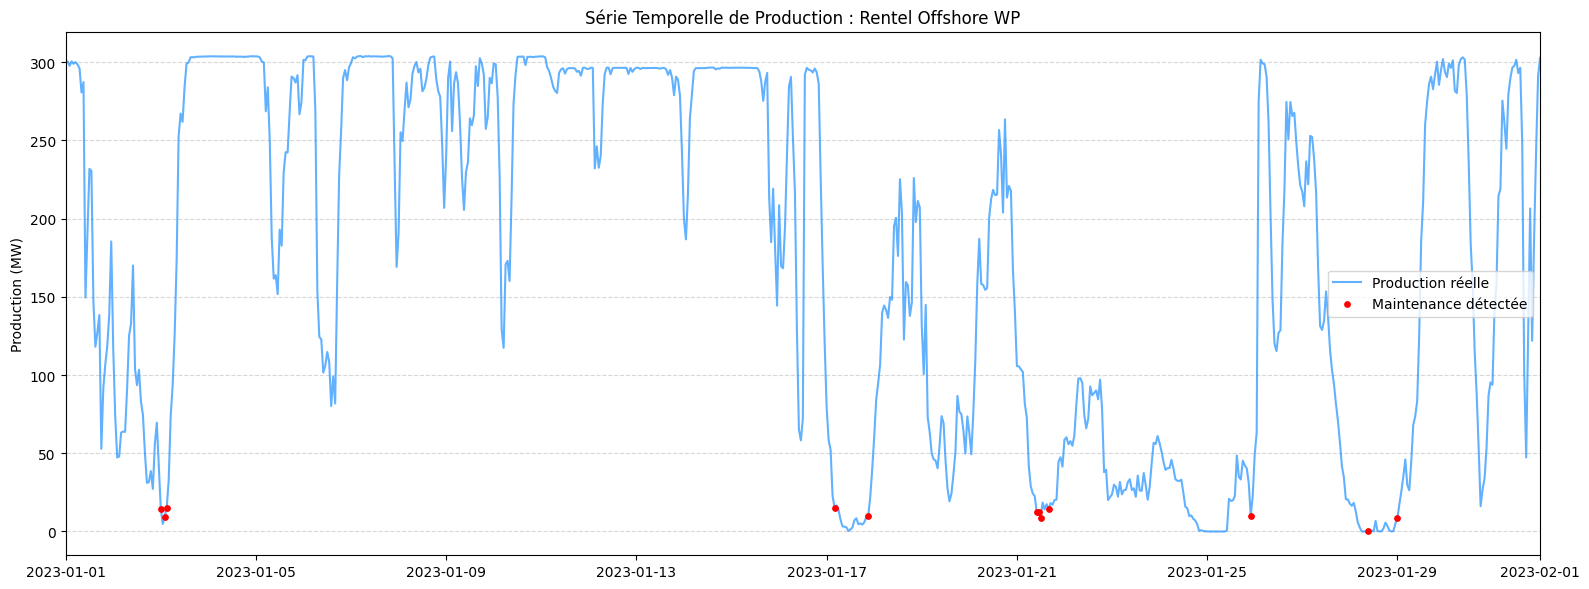

Seastar Offshore WP


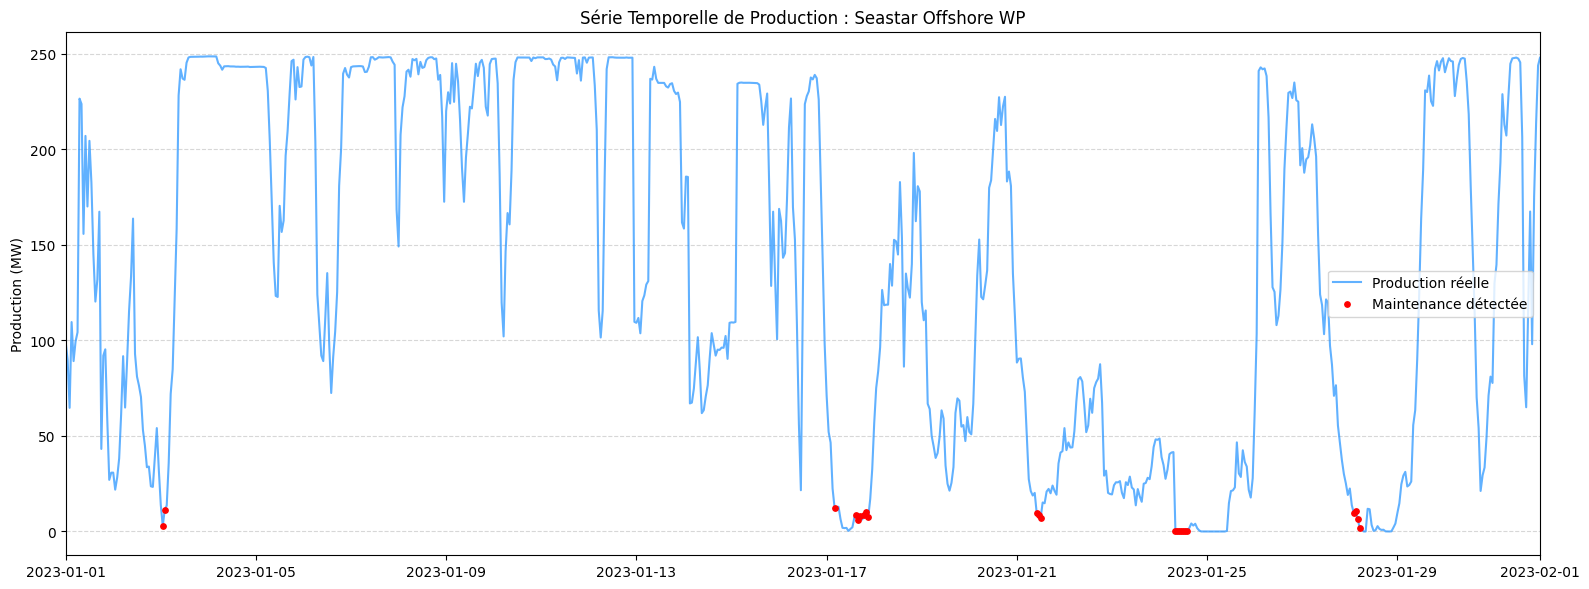

Thorntonbank - C-Power - Area NE


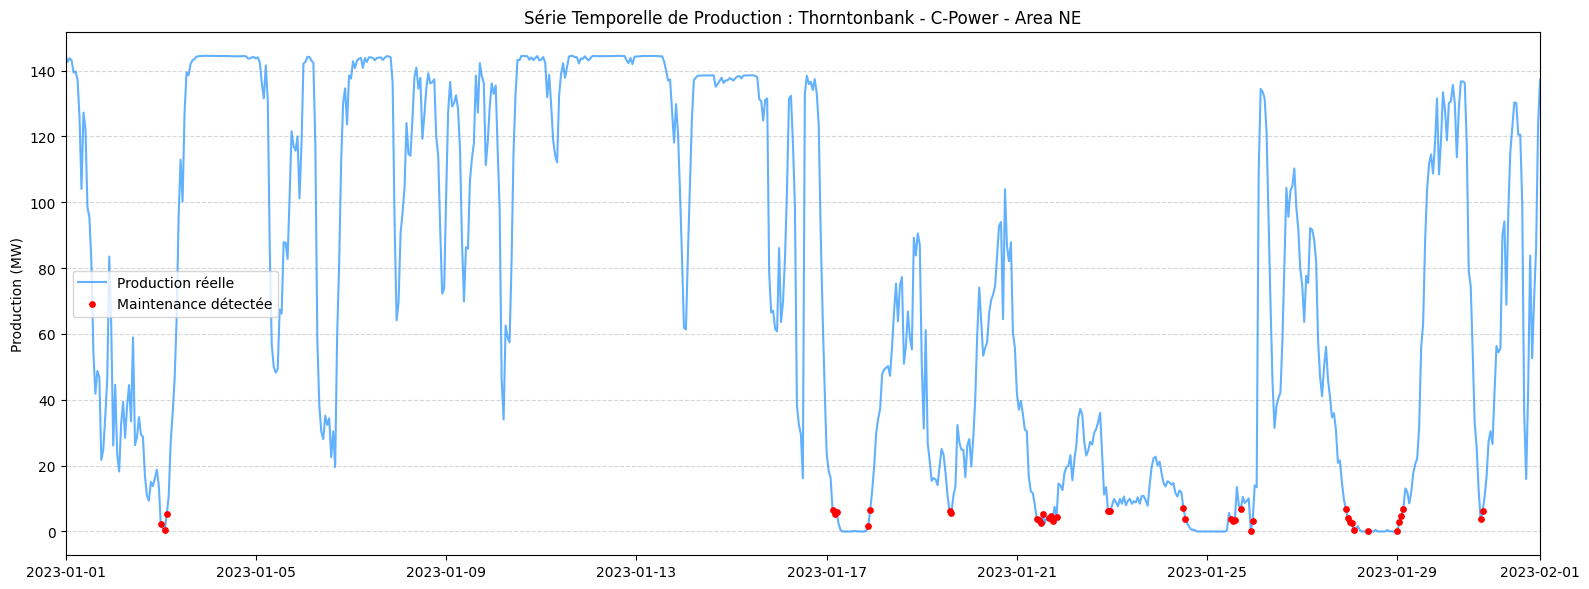

Thorntonbank - C-Power - Area SW


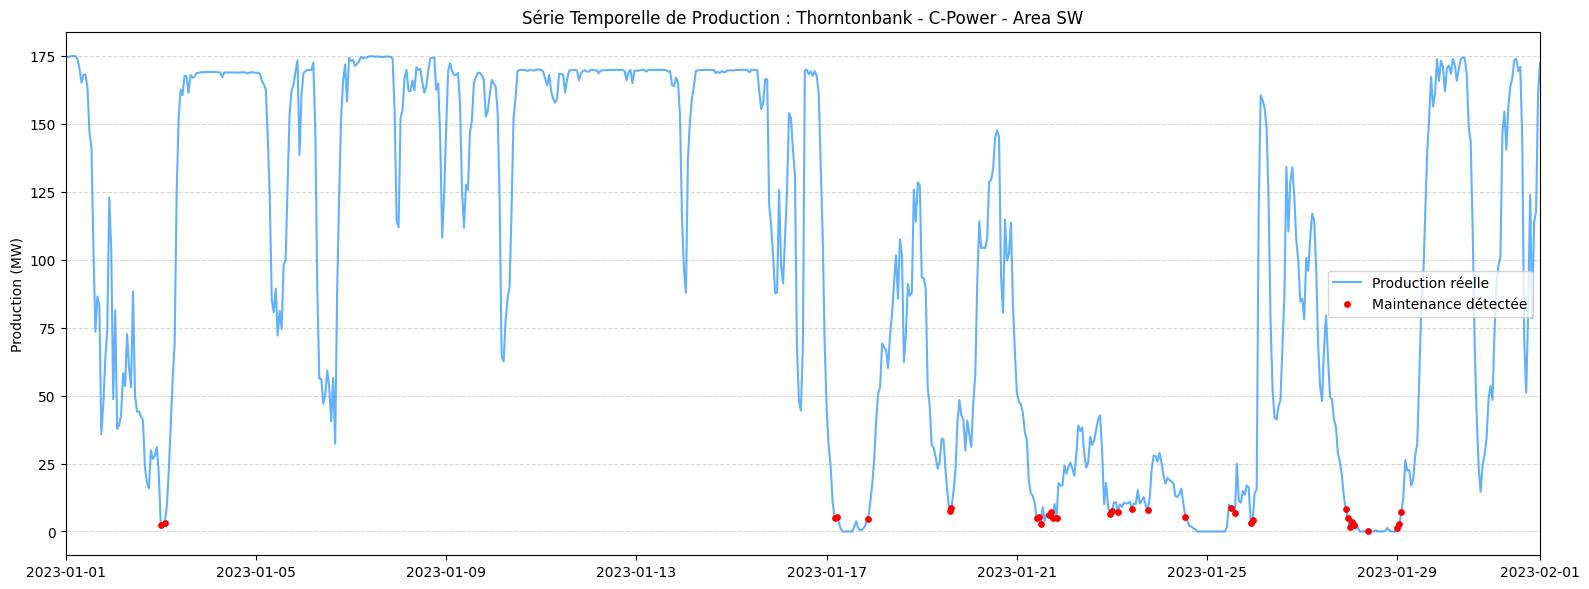

In [13]:
for site_name in df["site_name"].unique():
    print(site_name)
    plot_production_time_series_with_maintenance(df, site_name, wind_threshold=wind_threshold, prod_threshold=prod_threshold)

In [14]:
def apply_maintenance_logic_site(df, site_name, wind_limit=5.0, cap_limit=0.05):
    """
    Identifie les maintenances en utilisant la capacité installée.
    
    Args:
        df: DataFrame fusionné
        wind_limit: Vitesse du vent min pour attendre une production (m/s)
        cap_limit: Ratio min de la capacité installée (0.05 = 5%)
    """
    data = df[df['site_name'] == site_name].copy()
    data['is_maintenance'] = (
        (data['wind_speed_100m'] > wind_limit) & 
        (data['production'] < (data['installed_capacity'] * cap_limit))
    ).astype(int)
    
    nb_maint = data['is_maintenance'].sum()
    print(f"Détection terminée : {nb_maint} heures de maintenance identifiées.")
    
    return data

In [15]:
for site_name in df.site_name.unique():
    print(site_name)
    site_df = apply_maintenance_logic_site(df, site_name, wind_limit=wind_threshold, cap_limit=prod_threshold)

Belwind Phase 1
Détection terminée : 3283 heures de maintenance identifiées.
Mermaid Offshore WP
Détection terminée : 1754 heures de maintenance identifiées.
Nobelwind Offshore Windpark
Détection terminée : 2260 heures de maintenance identifiées.
Norther Offshore WP
Détection terminée : 2075 heures de maintenance identifiées.
Northwester 2
Détection terminée : 3169 heures de maintenance identifiées.
Northwind
Détection terminée : 2956 heures de maintenance identifiées.
Rentel Offshore WP
Détection terminée : 2373 heures de maintenance identifiées.
Seastar Offshore WP
Détection terminée : 2447 heures de maintenance identifiées.
Thorntonbank - C-Power - Area NE
Détection terminée : 3905 heures de maintenance identifiées.
Thorntonbank - C-Power - Area SW
Détection terminée : 3207 heures de maintenance identifiées.


In [16]:
def apply_maintenance_logic(data, wind_limit=5.0, cap_limit=0.05):
    """
    Identifie les maintenances en utilisant la capacité installée.
    
    Args:
        df: DataFrame fusionné
        wind_limit: Vitesse du vent min pour attendre une production (m/s)
        cap_limit: Ratio min de la capacité installée (0.05 = 5%)
    """
    data['is_maintenance'] = (
        (data['wind_speed_100m'] > wind_limit) & 
        (data['production'] < (data['installed_capacity'] * cap_limit))
    ).astype(int)
    
    nb_maint = data['is_maintenance'].sum()
    print(f"Détection terminée : {nb_maint} heures de maintenance identifiées.")
    
    return data

In [17]:
maintenance_df = apply_maintenance_logic(df, wind_limit=wind_threshold, cap_limit=prod_threshold)

Détection terminée : 27429 heures de maintenance identifiées.


Les maintenances durent rarement qu'une seule heure, si il n'y en a qu'une d'isolée c'est surement une erreur et sinon si il y en a plusieurs d'affilé c'est une vrai maintenance. 

Parfois, le gestionnaire de réseau demande d'arrêter les éoliennes car il y a trop d'électricité sur le réseau. Pour éliminer ces maintenances aussi il faut regarder si les maintenances arrivent souvent au même moment sur tous les parcs en même temps.

In [18]:
maintenance_df['maint_rolling_sum'] = maintenance_df.groupby('site_name')['is_maintenance'].transform(
        lambda x: x.rolling(window=3, center=True).sum()
    )
# On confirme si il y en a 2 sur les 3 dse la fenêtre
maintenance_df['is_confirmed_maint'] = ((maintenance_df['is_maintenance'] == 1) & (maintenance_df['maint_rolling_sum'] >= 2)).astype(int)

In [19]:
# On calcule combien de sites sont en 'maintenance' à chaque heure
sites_in_maint_count = maintenance_df.groupby('delivery_time')['is_confirmed_maint'].transform('sum')
total_sites = maintenance_df['site_name'].nunique()
maintenance_df['is_curtailment'] = ((maintenance_df['is_confirmed_maint'] == 1) & (sites_in_maint_count > (total_sites / 2))).astype(int)
maintenance_df['to_drop_for_training'] = (maintenance_df['is_confirmed_maint'] == 1) | (maintenance_df['is_curtailment'] == 1)

In [20]:
print(f"Maintenances isolées supprimées (Faux positifs) : {maintenance_df['is_maintenance'].sum() - maintenance_df['is_confirmed_maint'].sum()}")
print(f"Heures identifiées comme Bridage Réseau (simultané) : {maintenance_df['is_curtailment'].sum()}")

Maintenances isolées supprimées (Faux positifs) : 3814
Heures identifiées comme Bridage Réseau (simultané) : 15401


In [21]:
def plot_maintenance_zoom(df, site_name, start_date, end_date):
    """Affiche un zoom temporel avec les points supprimés en rouge."""
    # Préparation des données
    temp_df = df[(df['site_name'] == site_name)].copy()
    temp_df['delivery_time'] = pd.to_datetime(temp_df['delivery_time']).dt.tz_localize(None)
    mask = (temp_df['delivery_time'] >= start_date) & (temp_df['delivery_time'] <= end_date)
    data_zoom = temp_df[mask].sort_values('delivery_time')

    plt.figure(figsize=(15, 6))
    
    # Production conservée (Bleu)
    clean_data = data_zoom[data_zoom['to_drop_for_training'] == 0]
    plt.plot(data_zoom['delivery_time'], data_zoom['production'], color='lightgray', alpha=0.5, label='Signal Brut')
    plt.scatter(clean_data['delivery_time'], clean_data['production'], color='dodgerblue', s=20, label='Production Conservée')

    # Points supprimés (Rouge)
    dropped_data = data_zoom[data_zoom['to_drop_for_training'] == 1]
    plt.scatter(dropped_data['delivery_time'], dropped_data['production'], color='red', s=30, marker='x', label='Dropped (Maint/Curtailment)')

    plt.title(f'Zoom Nettoyage : {site_name} ({start_date} au {end_date})')
    plt.ylabel('Production (MW)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [22]:
def plot_multi_site_curtailment(df, start_date, end_date):
    """Visualise le bridage simultané sur plusieurs parcs."""
    temp_df = df.copy()
    temp_df['delivery_time'] = pd.to_datetime(temp_df['delivery_time']).dt.tz_localize(None)
    mask = (temp_df['delivery_time'] >= start_date) & (temp_df['delivery_time'] <= end_date)
    data_plot = temp_df[mask]

    # Création d'une heatmap ou d'un scatter plot par site
    plt.figure(figsize=(15, 8))
    sites = data_plot['site_name'].unique()
    
    for i, site in enumerate(sites):
        site_data = data_plot[data_plot['site_name'] == site].sort_values('delivery_time')
        # On trace une ligne de base
        plt.plot(site_data['delivery_time'], [i]*len(site_data), color='lightgray', alpha=0.3)
        
        # On marque les moments de "to_drop_for_training"
        drops = site_data[site_data['to_drop_for_training'] == 1]
        plt.scatter(drops['delivery_time'], [i]*len(drops), color='red', marker='|', s=100)

    plt.yticks(range(len(sites)), sites)
    plt.title('Analyse de simultanéité des arrêts (Preuve de Bridage Réseau)')
    plt.xlabel('Temps')
    plt.grid(True, axis='x', alpha=0.2)
    plt.tight_layout()
    plt.show()

----------------------------------------
Belwind Phase 1


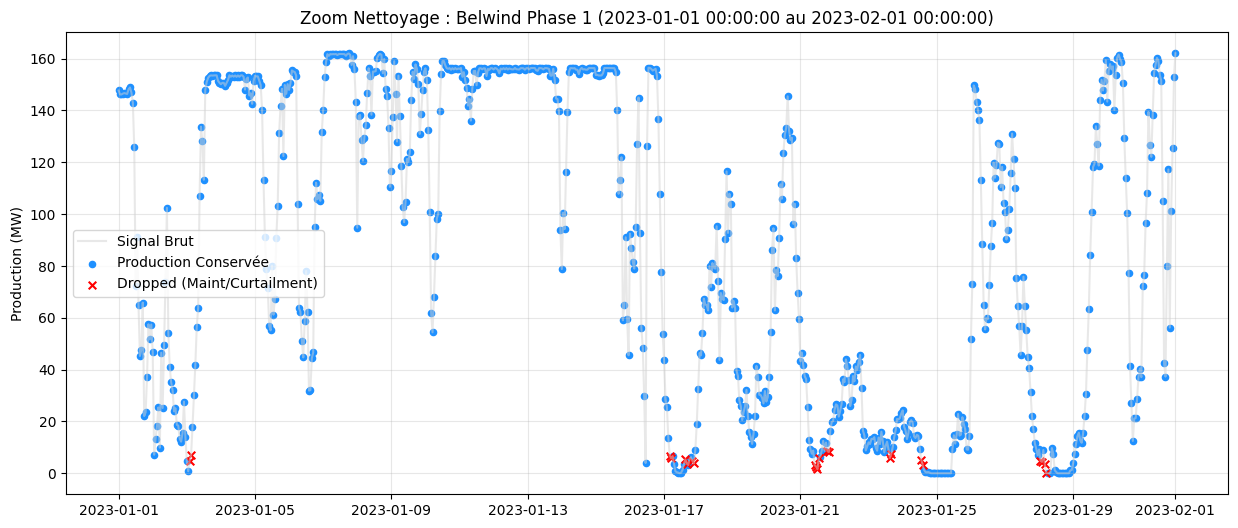

----------------------------------------
Mermaid Offshore WP


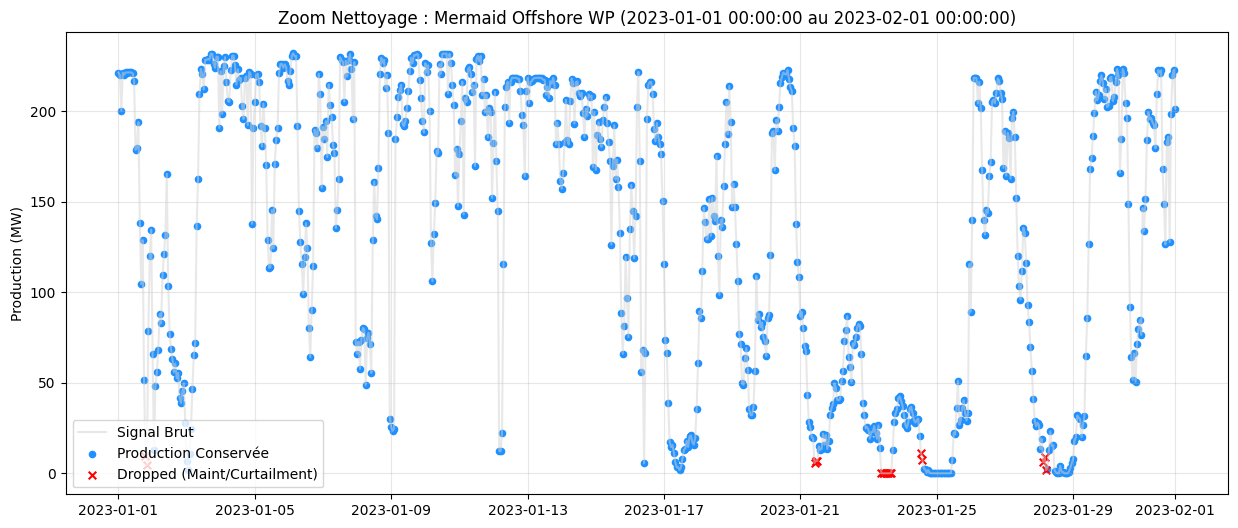

----------------------------------------
Nobelwind Offshore Windpark


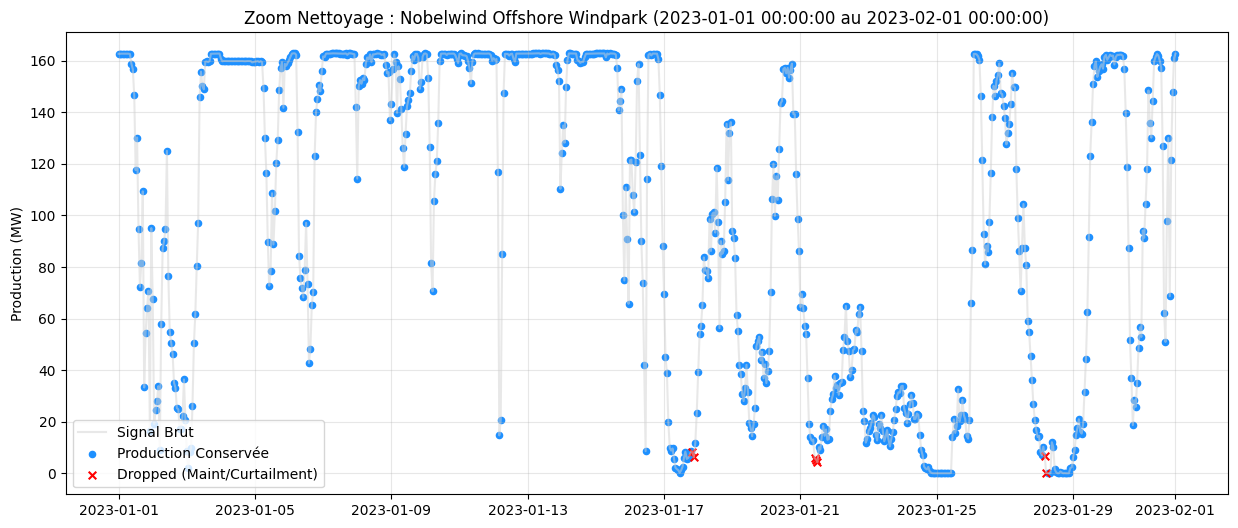

----------------------------------------
Norther Offshore WP


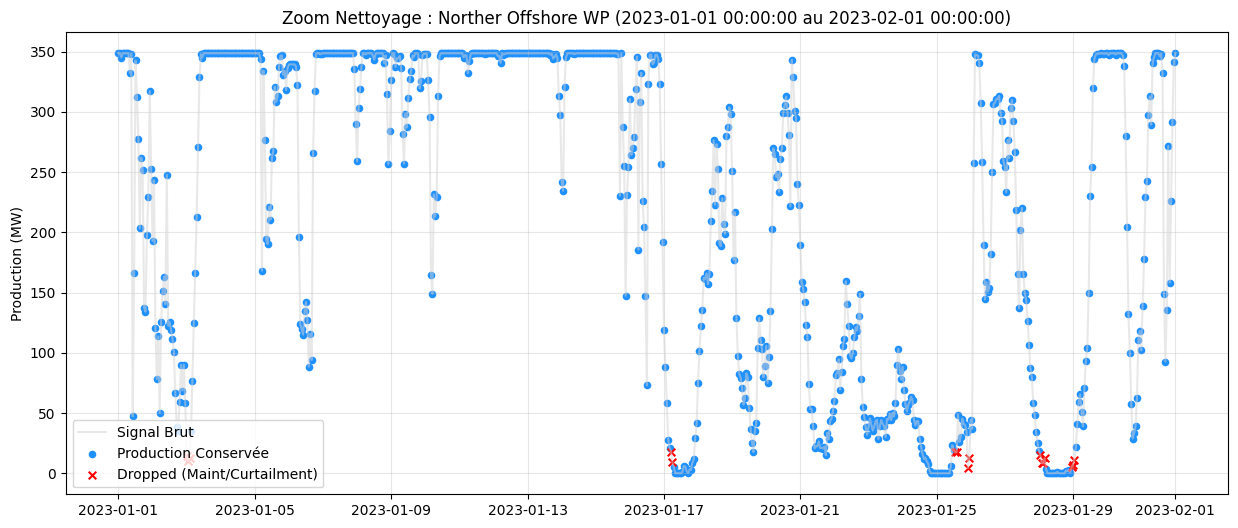

----------------------------------------
Northwester 2


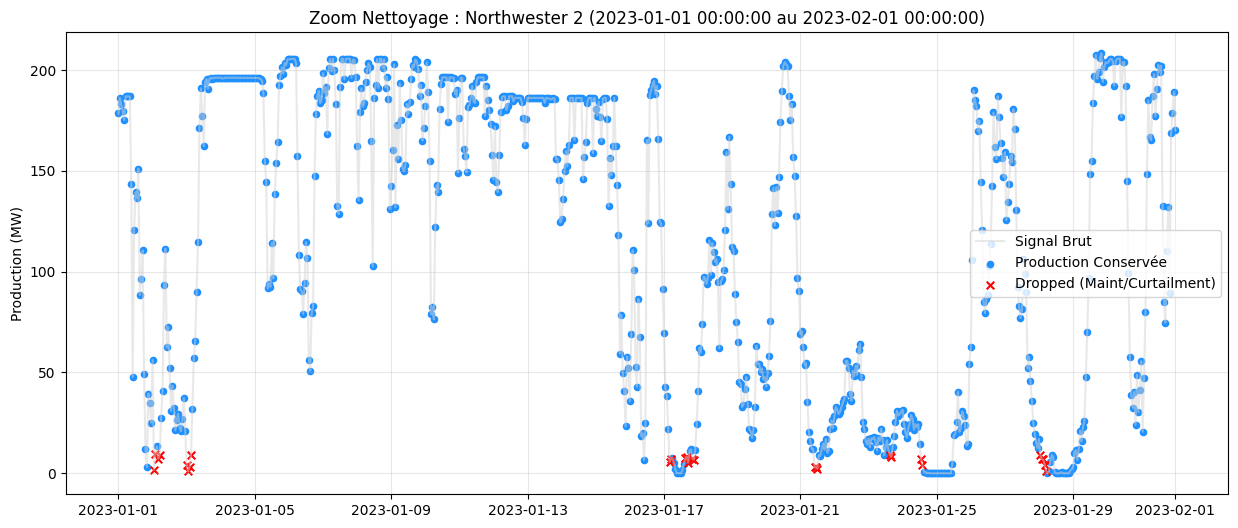

----------------------------------------
Northwind


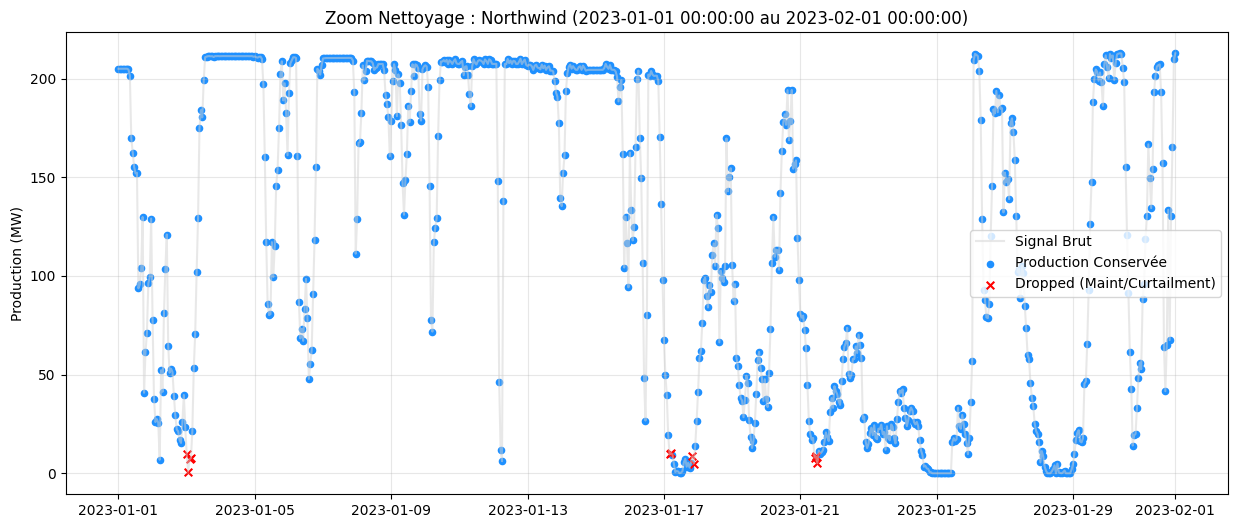

----------------------------------------
Rentel Offshore WP


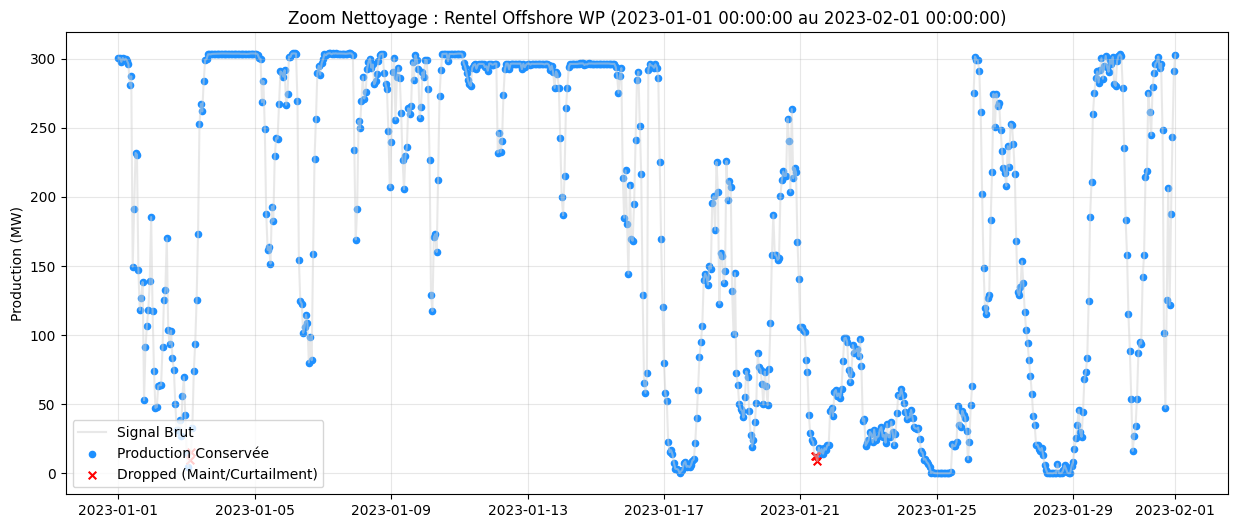

----------------------------------------
Seastar Offshore WP


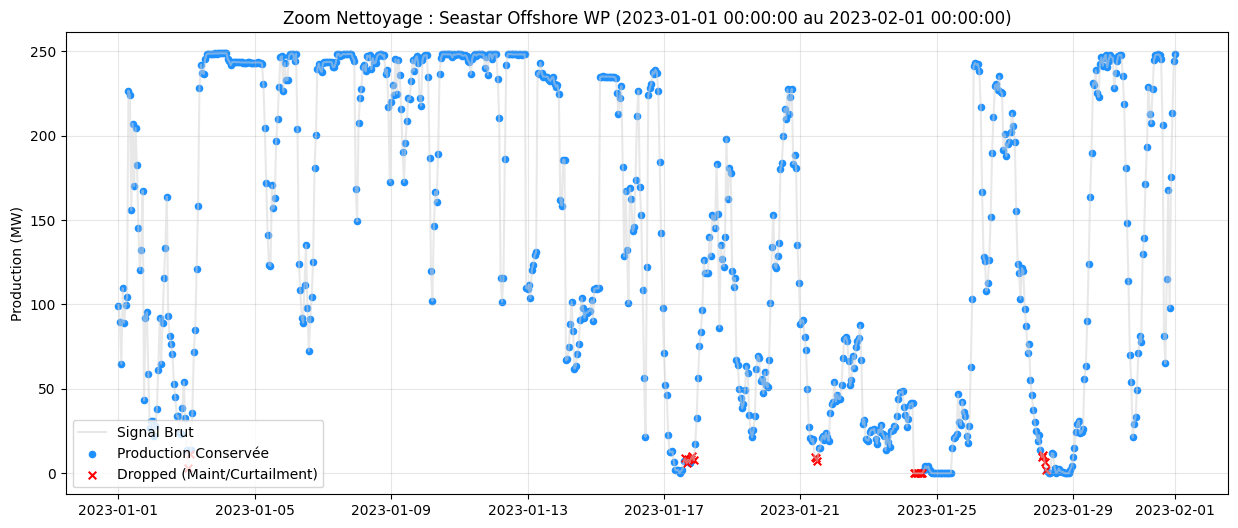

----------------------------------------
Thorntonbank - C-Power - Area NE


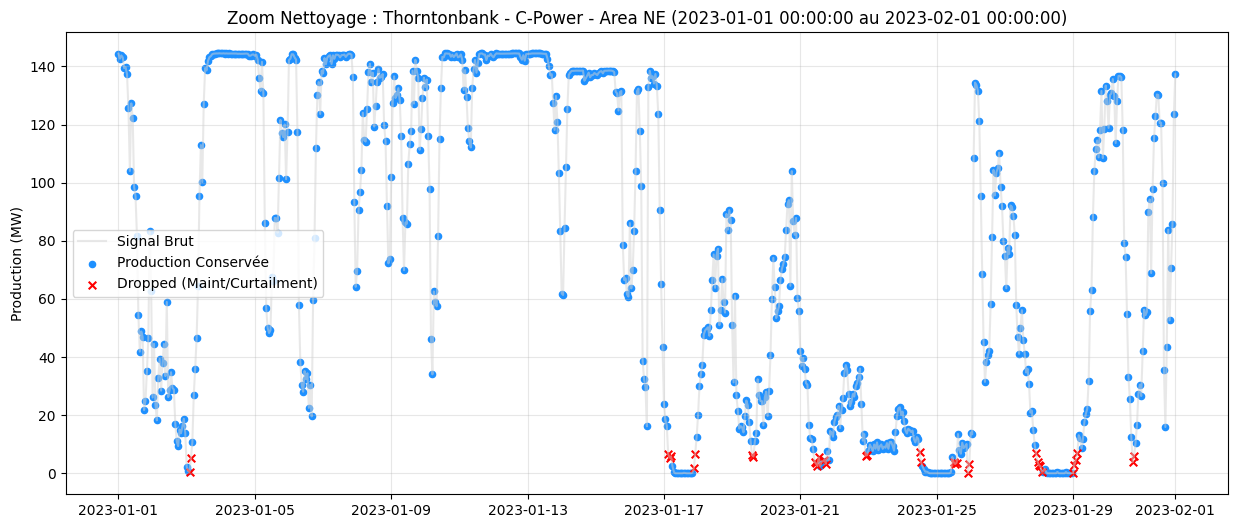

----------------------------------------
Thorntonbank - C-Power - Area SW


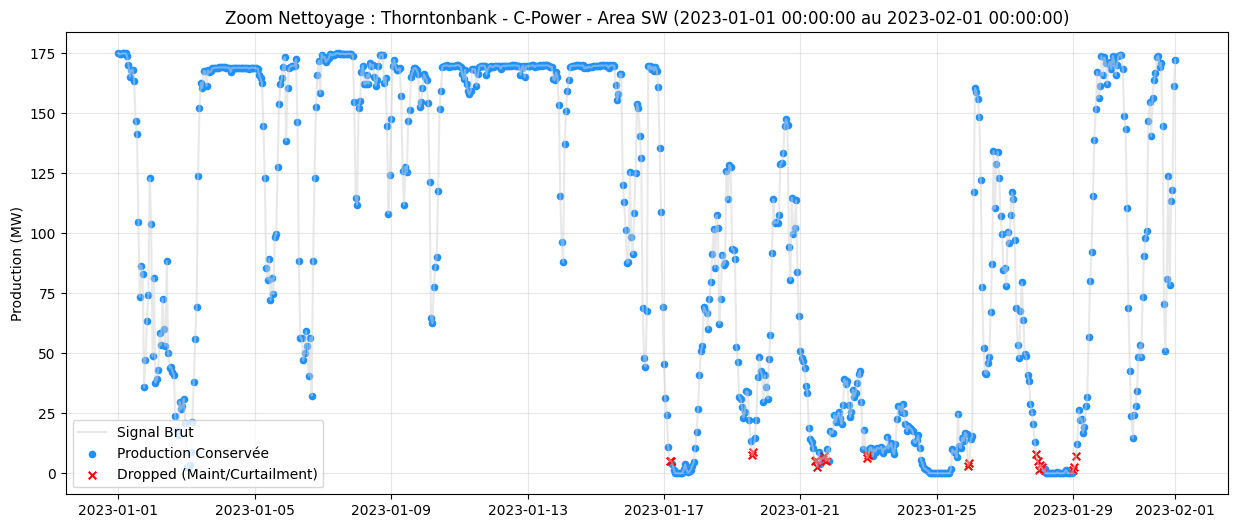

In [23]:
for site_name in df.site_name.unique():
    print("-"*40)
    print(site_name)
    start_date, end_date = pd.Timestamp("2023-01-01"), pd.Timestamp("2023-02-01")
    plot_maintenance_zoom(df, site_name, start_date, end_date)

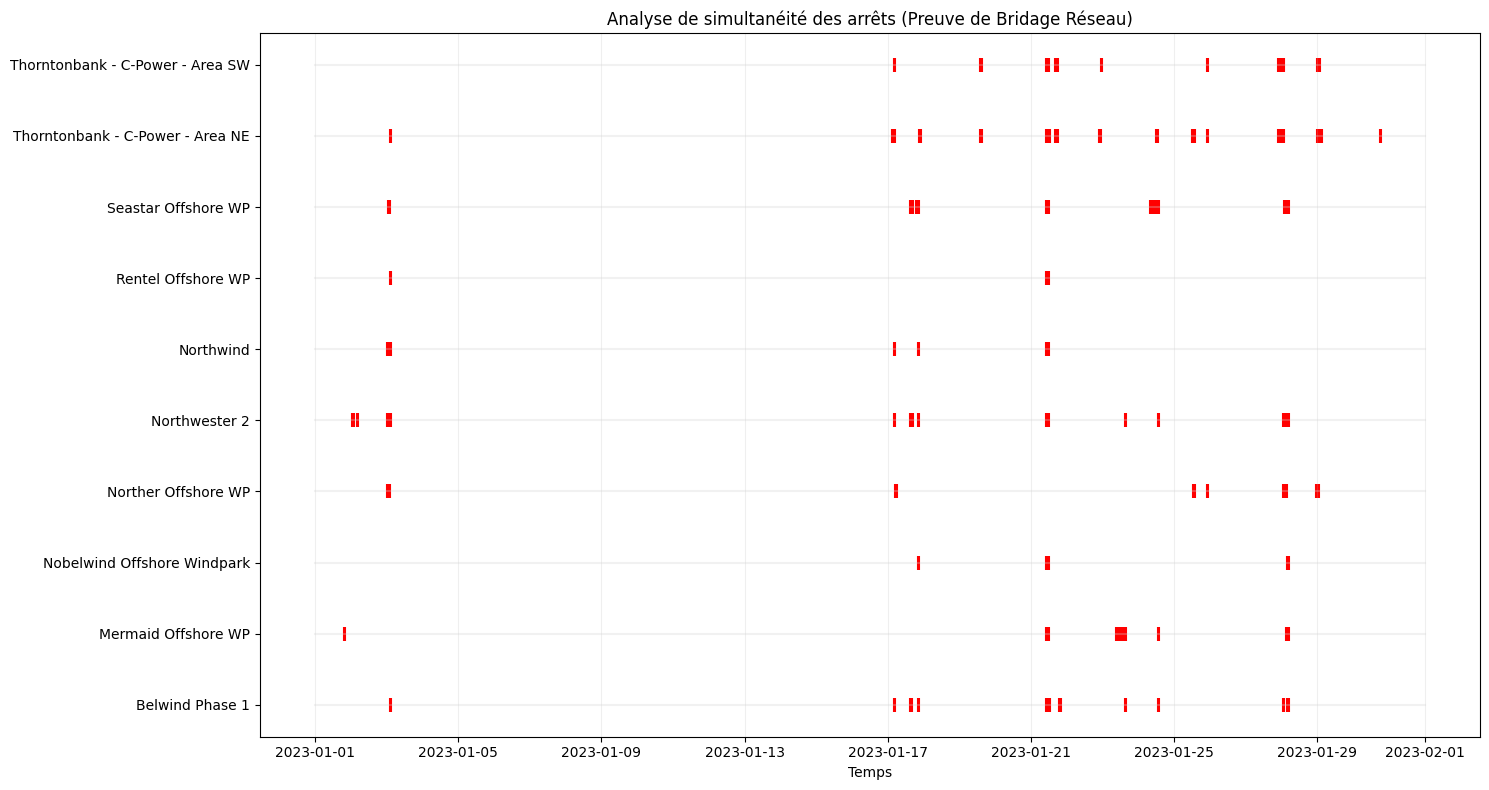

In [24]:
plot_multi_site_curtailment(df, start_date, end_date)

In [25]:
def extend_maintenance_periods(df, hours_buffer=2):
    """
    Étend les périodes de maintenance de ±hours_buffer heures.
    
    Args:
        df: DataFrame avec colonne 'to_drop_for_training'
        hours_buffer: Nombre d'heures à ajouter avant et après chaque maintenance
    """
    df = df.copy()
    df['delivery_time'] = pd.to_datetime(df['delivery_time'])
    
    for site in df['site_name'].unique():
        site_mask = df['site_name'] == site
        site_indices = df[site_mask].index
        site_data = df.loc[site_indices].sort_values('delivery_time')
        
        site_data_copy = site_data.copy()
        site_data_copy['to_drop_for_training'] = df.loc[site_data.index, 'to_drop_for_training']
        site_data_copy['maint_group'] = (site_data_copy['to_drop_for_training'].diff() != 0).cumsum()
        
        for group_idx in site_data_copy['maint_group'].unique():
            group = site_data_copy[site_data_copy['maint_group'] == group_idx]
            
            if group['to_drop_for_training'].iloc[0] == 1:
                start_time = group['delivery_time'].min() - pd.Timedelta(hours=hours_buffer)
                end_time = group['delivery_time'].max() + pd.Timedelta(hours=hours_buffer)
                
                mask = (df['site_name'] == site) & (df['delivery_time'] >= start_time) & (df['delivery_time'] <= end_time)
                df.loc[mask, 'to_drop_for_training'] = True
    
    return df

maintenance_df = extend_maintenance_periods(maintenance_df, hours_buffer=2)
print(f"Après extension (±2h) : {maintenance_df['to_drop_for_training'].sum()} heures à supprimer")

Après extension (±2h) : 45221 heures à supprimer


In [26]:
total_rows_before = len(maintenance_df)
rows_to_drop = (maintenance_df['to_drop_for_training'] == 1).sum()
proportion = (rows_to_drop / total_rows_before) * 100

print(f"Total de lignes : {total_rows_before}")
print(f"Lignes à supprimer : {rows_to_drop}")
print(f"Proportion supprimée : {proportion:.2f}%")
print(f"Lignes conservées : {total_rows_before - rows_to_drop} ({100 - proportion:.2f}%)")
print("-" * 50)

Total de lignes : 274790
Lignes à supprimer : 45221
Proportion supprimée : 16.46%
Lignes conservées : 229569 (83.54%)
--------------------------------------------------


In [27]:
mask_drop = maintenance_df['to_drop_for_training'] == 1
columns_to_nan = ['production']

for col in columns_to_nan:
    maintenance_df.loc[mask_drop, col] = np.nan

print(f"NaN introduits dans les colonnes : {columns_to_nan}")
print(f"Vérification - NaN dans 'production' : {maintenance_df['production'].isna().sum()}")

NaN introduits dans les colonnes : ['production']
Vérification - NaN dans 'production' : 45221


In [28]:
cleaned_df = maintenance_df.dropna(subset=['production']).copy()

print(f"Lignes conservées après suppression : {len(cleaned_df)}")
print(f"Lignes supprimées : {len(maintenance_df) - len(cleaned_df)}")

Lignes conservées après suppression : 229569
Lignes supprimées : 45221


In [29]:
output_path = "../data/cleaned_dataset.csv"
cleaned_df.to_csv(output_path, index=False)
print(f"\nDataset nettoyé sauvegardé : {output_path}")
print(f"Proportion conservée : {(len(cleaned_df)/total_rows_before)*100:.2f}%")


Dataset nettoyé sauvegardé : ../data/cleaned_dataset.csv
Proportion conservée : 83.54%
